In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

# load the feature CSV from preproc
_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == "EDA" else _cwd
DATA_CSV = os.path.join(_root, "data", "eegmat", "eegmat_bandpower_segments.csv")

df = pd.read_csv(DATA_CSV)

# quick sanity check on the data
print("Shape:", df.shape)
print("\nLabel counts (0 = baseline, 1 = task):")
print(df["label"].value_counts())
print("\nFirst few rows:")
df.head()

Shape: (4338, 68)

Label counts (0 = baseline, 1 = task):
label
0    3222
1    1116
Name: count, dtype: int64

First few rows:


,subject_id,recording_id,segment_idx,label,theta_EEG Fp1,theta_EEG Fp2,theta_EEG F3,theta_EEG F4,theta_EEG F7,theta_EEG F8,...,beta_EEG O1,beta_EEG O2,beta_EEG Fz,beta_EEG Cz,beta_EEG Pz,beta_EEG A2-A1,csp_1,csp_2,csp_3,csp_4
0,0,baseline,0,0,8.230781e-12,1.089378e-11,1.108751e-11,8.070233e-12,1.356126e-11,1.727897e-11,...,2.442675e-11,4.053214e-11,5.960407e-12,8.637142e-12,1.412838e-11,1.141470e-12,-0.562606,-1.661963,-0.642091,-0.988254
1,0,baseline,1,0,9.268282e-12,8.892937e-12,1.769324e-11,1.535522e-11,1.610250e-11,8.165809e-12,...,7.175125e-12,1.002375e-11,1.269855e-11,1.287391e-11,7.009352e-12,1.220406e-12,-1.547352,-1.030722,-0.680744,-0.121777
2,0,baseline,2,0,6.321962e-12,1.139815e-11,6.747887e-12,9.530494e-12,8.112675e-12,1.005060e-11,...,2.059991e-11,2.421764e-11,2.212177e-11,2.274492e-11,1.436223e-11,1.111232e-12,-1.293483,-0.351056,0.135325,0.157243
3,0,baseline,3,0,8.996813e-12,1.465802e-11,1.217375e-11,1.698796e-11,1.558309e-11,1.216414e-11,...,3.987606e-11,2.561226e-11,1.934992e-11,2.807244e-11,4.411119e-11,2.123295e-12,-0.492691,-0.933370,-0.525653,-0.159155
4,0,baseline,4,0,7.759277e-12,1.132600e-11,1.631360e-11,1.181184e-11,1.842302e-11,7.851705e-12,...,3.548510e-11,3.288838e-11,1.603332e-11,1.877462e-11,1.961471e-11,2.833497e-12,-0.603247,-1.209633,-0.257809,-0.409020


In [2]:
# separate out the metadata columns from the actual features
meta_cols = ["subject_id", "recording_id", "segment_idx", "label"]
feature_cols = [c for c in df.columns if c not in meta_cols]

# X = features, y = labels, groups = subject IDs (used to prevent leakage)
X = df[feature_cols].values
y = df["label"].values
groups = df["subject_id"].values

print("Number of features:", len(feature_cols))
print("Feature names sample:", feature_cols[:6])
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Unique subjects:", len(np.unique(groups)))

Number of features: 64
Feature names sample: ['theta_EEG Fp1', 'theta_EEG Fp2', 'theta_EEG F3', 'theta_EEG F4', 'theta_EEG F7', 'theta_EEG F8']

X shape: (4338, 64)
y shape: (4338,)
Unique subjects: 36


In [13]:
# 3-way subject split: train (25) / val (5) / test (6)
# pick best model on val, report final numbers on test only
subjects = np.unique(groups)
rng = np.random.default_rng(42)
shuffled = rng.permutation(subjects)

test_subjects  = shuffled[:6]
val_subjects   = shuffled[6:11]
train_subjects = shuffled[11:]

train_mask = np.isin(groups, train_subjects)
val_mask   = np.isin(groups, val_subjects)
test_mask  = np.isin(groups, test_subjects)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {train_mask.sum()} segments | {len(train_subjects)} subjects")
print(f"Val:   {val_mask.sum()} segments | {len(val_subjects)} subjects")
print(f"Test:  {test_mask.sum()} segments | {len(test_subjects)} subjects")

Train: 2999 segments | 25 subjects
Val:   613 segments | 5 subjects
Test:  726 segments | 6 subjects


In [14]:
# train all three models on train set, pick best using val AUC
print("=" * 55)
print("TASK 1: Baseline vs Task Classification")
print("=" * 55)

models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                      ("clf", LogisticRegression(max_iter=1000))]),
    "SVM":                 Pipeline([("scaler", StandardScaler()),
                                      ("clf", SVC(kernel="rbf", probability=True))]),
    "Random Forest":       Pipeline([("scaler", StandardScaler()),
                                      ("clf", RandomForestClassifier(n_estimators=100, random_state=42))]),
}

val_results_t1 = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    val_results_t1[name] = {"model": model, "val_auc": val_auc}
    print(f"{name:25s} | Val AUC: {val_auc:.3f}")

best_name_t1 = max(val_results_t1, key=lambda k: val_results_t1[k]["val_auc"])
best_model_t1 = val_results_t1[best_name_t1]["model"]
print(f"\nBest model (chosen on val): {best_name_t1}")

TASK 1: Baseline vs Task Classification
Logistic Regression       | Val AUC: 0.693
SVM                       | Val AUC: 0.663
Random Forest             | Val AUC: 0.634

Best model (chosen on val): Logistic Regression


=== Task 1 TEST results (Logistic Regression) ===
AUC:               0.754
Balanced Accuracy: 0.559

              precision    recall  f1-score   support

    Baseline       0.77      0.96      0.85       540
        Task       0.57      0.16      0.25       186

    accuracy                           0.75       726
   macro avg       0.67      0.56      0.55       726
weighted avg       0.72      0.75      0.70       726



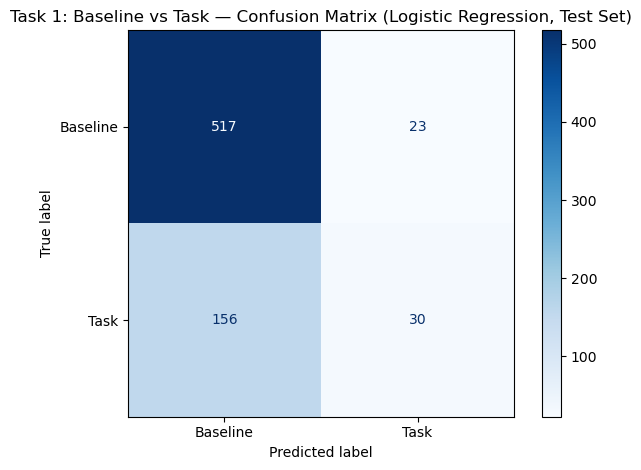

In [15]:
from sklearn.metrics import balanced_accuracy_score

# final evaluation on test set — only touched once
y_pred_t1 = best_model_t1.predict(X_test)
y_prob_t1 = best_model_t1.predict_proba(X_test)[:, 1]

test_auc_t1  = roc_auc_score(y_test, y_prob_t1)
test_bacc_t1 = balanced_accuracy_score(y_test, y_pred_t1)

print(f"=== Task 1 TEST results ({best_name_t1}) ===")
print(f"AUC:               {test_auc_t1:.3f}")
print(f"Balanced Accuracy: {test_bacc_t1:.3f}\n")
print(classification_report(y_test, y_pred_t1, target_names=["Baseline", "Task"]))

cm = confusion_matrix(y_test, y_pred_t1)
ConfusionMatrixDisplay(cm, display_labels=["Baseline", "Task"]).plot(cmap="Blues")
plt.title(f"Task 1: Baseline vs Task — Confusion Matrix ({best_name_t1}, Test Set)")
plt.tight_layout()
plt.show()

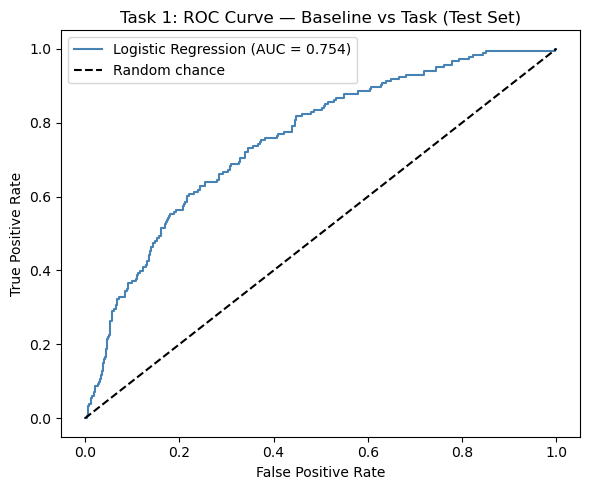

In [16]:
# ROC curve for Task 1 on test set
fpr, tpr, _ = roc_curve(y_test, y_prob_t1)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="steelblue", label=f"{best_name_t1} (AUC = {test_auc_t1:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Task 1: ROC Curve — Baseline vs Task (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

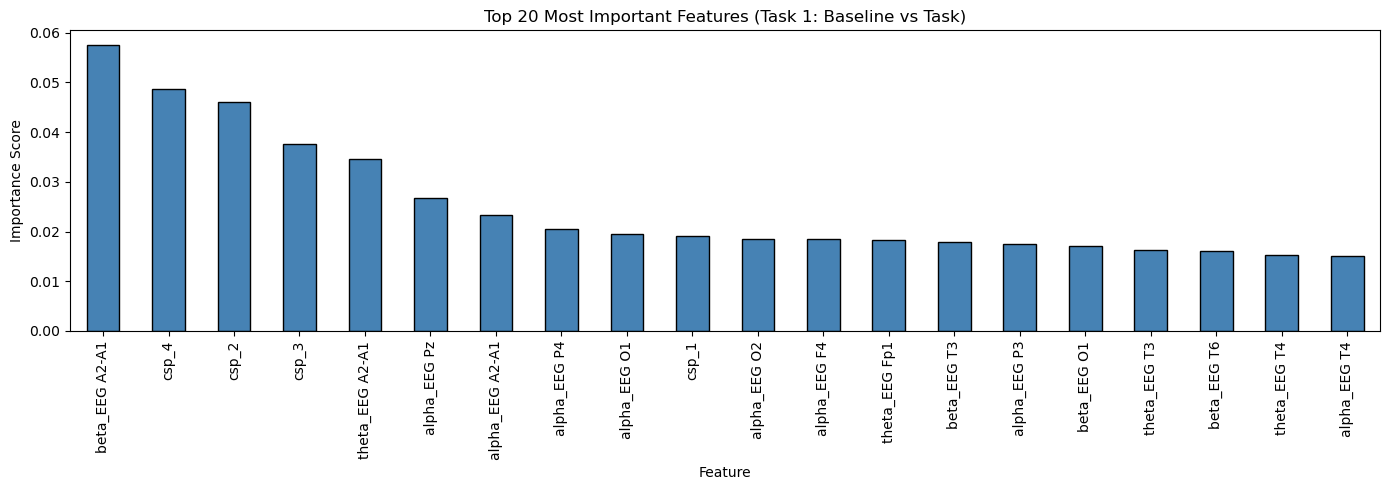


Total importance by band:
  theta     : 0.2561
  alpha     : 0.2992
  beta      : 0.2933
  csp       : 0.1514


In [17]:
# feature importance -- which bands/channels drive classification

# fit the model on the full dataset to get feature importances
pipe_fi = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe_fi.fit(X_train, y_train)

importances = pipe_fi.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)


feat_imp.head(20).plot(kind="bar", figsize=(14, 5), color="steelblue", edgecolor="black")
plt.title("Top 20 Most Important Features (Task 1: Baseline vs Task)")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

# summarize importance by frequency band
print("\nTotal importance by band:")
for band in ["theta", "alpha", "beta", "csp"]:
    cols = [c for c in feature_cols if c.startswith(band)]
    if cols:
        print(f"  {band:10s}: {feat_imp[cols].sum():.4f}")

In [19]:
# Task 2: hard vs easy within task segments
# stratify subject split so hard/easy are balanced across train/val/test
print("=" * 55)
print("TASK 2: Hard vs Easy (within Task segments only)")
print("=" * 55)

alpha_cols = [c for c in feature_cols if c.startswith("alpha_")]

# compute suppression for all subjects
def subject_alpha_suppression(df_in, subj_list):
    results = {}
    for s in subj_list:
        task_alpha = df_in[(df_in["subject_id"] == s) & (df_in["label"] == 1)][alpha_cols].mean().mean()
        base_alpha = df_in[(df_in["subject_id"] == s) & (df_in["label"] == 0)][alpha_cols].mean().mean()
        results[s] = base_alpha - task_alpha
    return results

all_suppression  = subject_alpha_suppression(df, np.unique(groups))
all_median       = np.median(list(all_suppression.values()))

# label each subject as hard (0) or easy (1)
subj_hardness = {s: (1 if all_suppression[s] >= all_median else 0) for s in np.unique(groups)}

hard_subjects = np.array([s for s in np.unique(groups) if subj_hardness[s] == 0])
easy_subjects = np.array([s for s in np.unique(groups) if subj_hardness[s] == 1])

print(f"Hard subjects: {len(hard_subjects)} | Easy subjects: {len(easy_subjects)}")

# stratified split: take proportional hard/easy in each split
rng2 = np.random.default_rng(42)
hard_shuf = rng2.permutation(hard_subjects)
easy_shuf = rng2.permutation(easy_subjects)

# ~3 test, ~2 val from each class
test_subj_t2  = np.concatenate([hard_shuf[:3],  easy_shuf[:3]])
val_subj_t2   = np.concatenate([hard_shuf[3:5], easy_shuf[3:5]])
train_subj_t2 = np.concatenate([hard_shuf[5:],  easy_shuf[5:]])

def assign_hardness(df_in, subj_list):
    rows = df_in[(df_in["subject_id"].isin(subj_list)) & (df_in["label"] == 1)].copy()
    rows["hard_easy"] = rows["subject_id"].map(subj_hardness)
    return rows

train_t2 = assign_hardness(df, train_subj_t2)
val_t2   = assign_hardness(df, val_subj_t2)
test_t2  = assign_hardness(df, test_subj_t2)

X_train_t2 = train_t2[feature_cols].values;  y_train_t2 = train_t2["hard_easy"].values
X_val_t2   = val_t2[feature_cols].values;    y_val_t2   = val_t2["hard_easy"].values
X_test_t2  = test_t2[feature_cols].values;   y_test_t2  = test_t2["hard_easy"].values

print(f"Train: {len(train_t2)} segments | Val: {len(val_t2)} | Test: {len(test_t2)}")
print(f"Val label balance: {y_val_t2.mean():.2f} | Test: {y_test_t2.mean():.2f}")

TASK 2: Hard vs Easy (within Task segments only)
Hard subjects: 18 | Easy subjects: 18
Train: 806 segments | Val: 124 | Test: 186
Val label balance: 0.50 | Test: 0.50


In [20]:
# train all models on Task 2, pick best using val AUC
models_t2 = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                      ("clf", LogisticRegression(max_iter=1000))]),
    "SVM":                 Pipeline([("scaler", StandardScaler()),
                                      ("clf", SVC(kernel="rbf", probability=True))]),
    "Random Forest":       Pipeline([("scaler", StandardScaler()),
                                      ("clf", RandomForestClassifier(n_estimators=100, random_state=42))]),
}

val_results_t2 = {}
for name, model in models_t2.items():
    model.fit(X_train_t2, y_train_t2)
    val_auc = roc_auc_score(y_val_t2, model.predict_proba(X_val_t2)[:, 1])
    val_results_t2[name] = {"model": model, "val_auc": val_auc}
    print(f"{name:25s} | Val AUC: {val_auc:.3f}")

best_name_t2  = max(val_results_t2, key=lambda k: val_results_t2[k]["val_auc"])
best_model_t2 = val_results_t2[best_name_t2]["model"]
print(f"\nBest model (chosen on val): {best_name_t2}")

Logistic Regression       | Val AUC: 0.614
SVM                       | Val AUC: 0.310
Random Forest             | Val AUC: 0.276

Best model (chosen on val): Logistic Regression


=== Task 2 TEST results (Logistic Regression) ===
AUC:               0.455
Balanced Accuracy: 0.516

              precision    recall  f1-score   support

        Hard       0.52      0.41      0.46        93
        Easy       0.51      0.62      0.56        93

    accuracy                           0.52       186
   macro avg       0.52      0.52      0.51       186
weighted avg       0.52      0.52      0.51       186



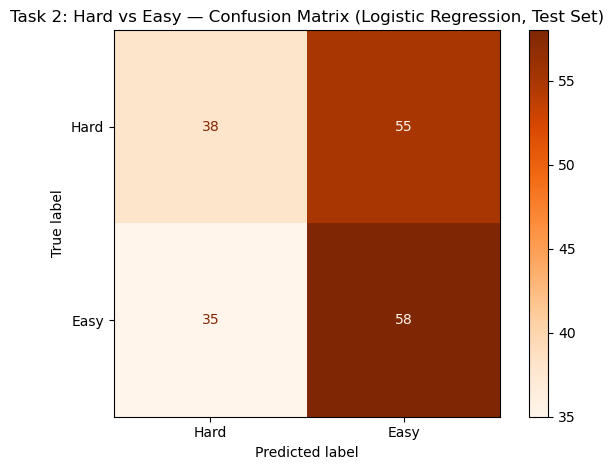

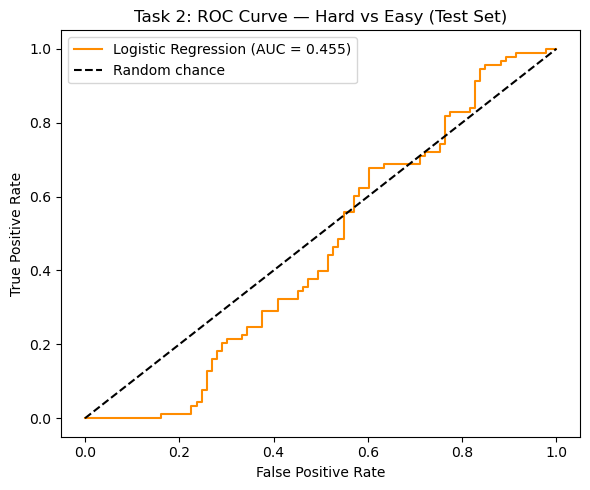

In [21]:
# Task 2 final evaluation on test set
y_pred_t2 = best_model_t2.predict(X_test_t2)
y_prob_t2 = best_model_t2.predict_proba(X_test_t2)[:, 1]

test_auc_t2  = roc_auc_score(y_test_t2, y_prob_t2)
test_bacc_t2 = balanced_accuracy_score(y_test_t2, y_pred_t2)

print(f"=== Task 2 TEST results ({best_name_t2}) ===")
print(f"AUC:               {test_auc_t2:.3f}")
print(f"Balanced Accuracy: {test_bacc_t2:.3f}\n")
print(classification_report(y_test_t2, y_pred_t2, target_names=["Hard", "Easy"]))

cm2 = confusion_matrix(y_test_t2, y_pred_t2)
ConfusionMatrixDisplay(cm2, display_labels=["Hard", "Easy"]).plot(cmap="Oranges")
plt.title(f"Task 2: Hard vs Easy — Confusion Matrix ({best_name_t2}, Test Set)")
plt.tight_layout()
plt.show()

fpr2, tpr2, _ = roc_curve(y_test_t2, y_prob_t2)
plt.figure(figsize=(6, 5))
plt.plot(fpr2, tpr2, color="darkorange", label=f"{best_name_t2} (AUC = {test_auc_t2:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Task 2: ROC Curve — Hard vs Easy (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# summary of final results
print(f"{'Task':<35} {'Best Model':<25} {'Val AUC':>8} {'Test AUC':>9} {'Test BalAcc':>12}")
print("-" * 92)
print(f"{'Task 1: Baseline vs Task':<35} {best_name_t1:<25} {val_results_t1[best_name_t1]['val_auc']:>8.3f} {test_auc_t1:>9.3f} {test_bacc_t1:>12.3f}")
print(f"{'Task 2: Hard vs Easy':<35} {best_name_t2:<25} {val_results_t2[best_name_t2]['val_auc']:>8.3f} {test_auc_t2:>9.3f} {test_bacc_t2:>12.3f}")

Task                                Best Model                 Val AUC  Test AUC  Test BalAcc
--------------------------------------------------------------------------------------------
Task 1: Baseline vs Task            Logistic Regression          0.693     0.754        0.559
Task 2: Hard vs Easy                Logistic Regression          0.614     0.455        0.516


In [23]:
# save final results
summary_data = [
    {
        "task":           "Task1_baseline_vs_task",
        "best_model":     best_name_t1,
        "val_auc":        round(val_results_t1[best_name_t1]["val_auc"], 3),
        "test_auc":       round(test_auc_t1, 3),
        "test_bal_acc":   round(test_bacc_t1, 3),
    },
    {
        "task":           "Task2_hard_vs_easy",
        "best_model":     best_name_t2,
        "val_auc":        round(val_results_t2[best_name_t2]["val_auc"], 3),
        "test_auc":       round(test_auc_t2, 3),
        "test_bal_acc":   round(test_bacc_t2, 3),
    },
]

results_df = pd.DataFrame(summary_data)
RESULTS_CSV = os.path.join(_root, "data", "eegmat", "model_results_summary.csv")
results_df.to_csv(RESULTS_CSV, index=False)

print("Results saved to:", RESULTS_CSV)
print(results_df.to_string(index=False))

Results saved to: /Users/anshpatel/Desktop/workload/data/eegmat/model_results_summary.csv
                  task          best_model  val_auc  test_auc  test_bal_acc
Task1_baseline_vs_task Logistic Regression    0.693     0.754         0.559
    Task2_hard_vs_easy Logistic Regression    0.614     0.455         0.516
